Feature Engineering means: Make smarter the data

Creating new useful features (columns) from existing data to help the model learn better.
Complete Machine Learning Workflow

This is how a real project looks.
Collect Data
      │
      ▼
Understand Data
      │
      ▼
EDA
      │
      ▼
Data Cleaning
      │
      ▼
Feature Engineering
      │
      ▼
Feature Selection
      │
      ▼
Split Train/Test
      │
      ▼
Scaling & Encoding
      │
      ▼
Build Model
      │
      ▼
Evaluate
      │
      ▼
Improve
      │
      ▼
Deploy

EDA: Understand data, Question like: How many missing values?

Any outliers?

Distribution?

Relationships?

Patterns?
EDA is like being a detective

Data Preprocessing: Fix data, Qustion like: Fill missing values

Encode text

Scale numbers

Remove duplicates

Prepare for ML

Data Preprocessing include: It includes much more:

Encoding
Scaling
Feature engineering
Pipelines
Transformations

## Lesson 2 — Data Cleaning (Industry-Level)

In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Employee_ID":[101,102,103,104,104,106,107,108],

    "Name":[
        "Abid",
        "Sara",
        "john",
        " Mina ",
        " Mina ",
        np.nan,
        "Alex",
        "EMMA"
    ],

    "Age":[
        22,
        "23",
        "Twenty Four",
        25,
        25,
        -3,
        29,
        np.nan
    ],

    "Department":[
        "IT",
        "HR",
        "IT",
        "Finance",
        "Finance",
        "IT",
        "hr",
        "Finance"
    ],

    "Salary":[
        30000,
        35000,
        np.nan,
        45000,
        45000,
        -5000,
        52000,
        60000
    ],

    "Join_Date":[
        "2023-01-15",
        "2022/05/10",
        "15-08-2021",
        "2023-07-20",
        "2023-07-20",
        "Unknown",
        "2024-01-05",
        "2024-02-30"
    ]
})

print(df)

   Employee_ID    Name          Age Department   Salary   Join_Date
0          101    Abid           22         IT  30000.0  2023-01-15
1          102    Sara           23         HR  35000.0  2022/05/10
2          103    john  Twenty Four         IT      NaN  15-08-2021
3          104   Mina            25    Finance  45000.0  2023-07-20
4          104   Mina            25    Finance  45000.0  2023-07-20
5          106     NaN           -3         IT  -5000.0     Unknown
6          107    Alex           29         hr  52000.0  2024-01-05
7          108    EMMA          NaN    Finance  60000.0  2024-02-30


In [2]:
df.head()

,Employee_ID,Name,Age,Department,Salary,Join_Date
0,101,Abid,22,IT,30000.0,2023-01-15
1,102,Sara,23,HR,35000.0,2022/05/10
2,103,john,Twenty Four,IT,NaN,15-08-2021
3,104,Mina,25,Finance,45000.0,2023-07-20
4,104,Mina,25,Finance,45000.0,2023-07-20


In [3]:
df.tail()

,Employee_ID,Name,Age,Department,Salary,Join_Date
3,104,Mina,25,Finance,45000.0,2023-07-20
4,104,Mina,25,Finance,45000.0,2023-07-20
5,106,NaN,-3,IT,-5000.0,Unknown
6,107,Alex,29,hr,52000.0,2024-01-05
7,108,EMMA,NaN,Finance,60000.0,2024-02-30


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Employee_ID  8 non-null      int64  
 1   Name         7 non-null      str    
 2   Age          7 non-null      object 
 3   Department   8 non-null      str    
 4   Salary       7 non-null      float64
 5   Join_Date    8 non-null      str    
dtypes: float64(1), int64(1), object(1), str(3)
memory usage: 516.0+ bytes


In [5]:
df.describe(include="all")

,Employee_ID,Name,Age,Department,Salary,Join_Date
count,8.000000,7,7.0,8,7.000000,8
unique,NaN,6,6.0,4,NaN,7
top,NaN,Mina,25.0,IT,NaN,2023-07-20
freq,NaN,2,2.0,3,NaN,2
mean,104.375000,NaN,NaN,NaN,37428.571429,NaN
std,2.445842,NaN,NaN,NaN,21204.222401,NaN
min,101.000000,NaN,NaN,NaN,-5000.000000,NaN
25%,102.750000,NaN,NaN,NaN,32500.000000,NaN
50%,104.000000,NaN,NaN,NaN,45000.000000,NaN
75%,106.250000,NaN,NaN,NaN,48500.000000,NaN


In [6]:
df.describe()

,Employee_ID,Salary
count,8.000000,7.000000
mean,104.375000,37428.571429
std,2.445842,21204.222401
min,101.000000,-5000.000000
25%,102.750000,32500.000000
50%,104.000000,45000.000000
75%,106.250000,48500.000000
max,108.000000,60000.000000


In [7]:
df.isnull().sum()

Employee_ID    0
Name           1
Age            1
Department     0
Salary         1
Join_Date      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df[df.duplicated()] # find duplicates rows

,Employee_ID,Name,Age,Department,Salary,Join_Date
4,104,Mina,25,Finance,45000.0,2023-07-20


In [10]:
df = df.drop_duplicates() # remove duplicates and return new dataframe

In [11]:
df.dtypes

Employee_ID      int64
Name               str
Age             object
Department         str
Salary         float64
Join_Date          str
dtype: object

In [13]:
df["Age"] = pd.to_numeric(
    df["Age"],
    errors="coerce"
) # errors="coerce" will convert non-numeric values to NaN

In [14]:
df["Department"] = (
    df["Department"]
      .str.strip()
      .str.title()
)

In [15]:
df["Name"] = (
    df["Name"]
      .str.strip()
      .str.title()
)

In [16]:
df[df["Age"] < 0]

,Employee_ID,Name,Age,Department,Salary,Join_Date
5,106,NaN,-3.0,It,-5000.0,Unknown


In [17]:
df[df["Salary"] < 0]

,Employee_ID,Name,Age,Department,Salary,Join_Date
5,106,NaN,-3.0,It,-5000.0,Unknown


In [18]:
df.loc[df["Age"] < 0, "Age"] = np.nan

In [ ]:
df.loc[df["Age"] < 0, "Age"] = np.nan # .loc[row_condition, column_name] to update only the problematic cells.

In [ ]:
df["Join_Date"] = pd.to_datetime(
    df["Join_Date"],
    errors="coerce"
) # nvalid dates become NaT (Not a Time), which is the datetime equivalent of NaN.

In [21]:
df

,Employee_ID,Name,Age,Department,Salary,Join_Date
0,101,Abid,22.0,It,30000.0,2023-01-15
1,102,Sara,23.0,Hr,35000.0,NaT
2,103,John,NaN,It,NaN,NaT
3,104,Mina,25.0,Finance,45000.0,2023-07-20
5,106,NaN,NaN,It,-5000.0,NaT
6,107,Alex,29.0,Hr,52000.0,2024-01-05
7,108,Emma,NaN,Finance,60000.0,NaT


In [22]:
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
Index: 7 entries, 0 to 7
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Employee_ID  7 non-null      int64         
 1   Name         6 non-null      str           
 2   Age          4 non-null      float64       
 3   Department   7 non-null      str           
 4   Salary       6 non-null      float64       
 5   Join_Date    3 non-null      datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 392.0 bytes
None
   Employee_ID  Name   Age Department   Salary  Join_Date
0          101  Abid  22.0         It  30000.0 2023-01-15
1          102  Sara  23.0         Hr  35000.0        NaT
2          103  John   NaN         It      NaN        NaT
3          104  Mina  25.0    Finance  45000.0 2023-07-20
5          106   NaN   NaN         It  -5000.0        NaT


In [23]:
df["Name"] = df["Name"].str.title()

In [24]:
df.isna().sum()

Employee_ID    0
Name           1
Age            3
Department     0
Salary         1
Join_Date      4
dtype: int64

In [27]:
"""
lesson.py

Mini Project:
Employee Data Inspection & Cleaning

Tasks:
1. Load the dataset
2. Inspect the dataset
3. Remove duplicate rows
4. Fix incorrect data types
5. Standardize text values
6. Handle impossible values
7. Convert date columns
8. Print before-and-after summaries

Author: Your Name
"""

# ==========================================================
# Import Libraries
# ==========================================================

import pandas as pd
import numpy as np

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.DataFrame({
    "Employee_ID":[101,102,103,104,104,106,107,108],

    "Name":[
        "Abid",
        "Sara",
        "john",
        " Mina ",
        " Mina ",
        np.nan,
        "Alex",
        "EMMA"
    ],

    "Age":[
        22,
        "23",
        "Twenty Four",
        25,
        25,
        -3,
        29,
        np.nan
    ],

    "Department":[
        "IT",
        "HR",
        "IT",
        "Finance",
        "Finance",
        "IT",
        "hr",
        "Finance"
    ],

    "Salary":[
        30000,
        35000,
        np.nan,
        45000,
        45000,
        -5000,
        52000,
        60000
    ],

    "Join_Date":[
        "2023-01-15",
        "2022/05/10",
        "15-08-2021",
        "2023-07-20",
        "2023-07-20",
        "Unknown",
        "2024-01-05",
        "2024-02-30"
    ]
})

print(df)

# ==========================================================
# BEFORE CLEANING SUMMARY
# ==========================================================

print("=" * 50)
print("BEFORE CLEANING")
print("=" * 50)

print("\nFirst Five Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nSummary Statistics")
print(df.describe(include="all"))

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# ------------------------------------------
# Remove Duplicates
# ------------------------------------------

duplicates_before = df.duplicated().sum()

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

# ------------------------------------------
# Fix Data Types
# ------------------------------------------

df["Age"] = pd.to_numeric(
    df["Age"],
    errors="coerce"
)

df["Salary"] = pd.to_numeric(
    df["Salary"],
    errors="coerce"
)

# ------------------------------------------
# Standardize Text
# ------------------------------------------

df["Name"] = (
    df["Name"]
    .str.strip()
    .str.title()
)

df["Department"] = (
    df["Department"]
    .str.strip()
    .str.upper()
)

df["Name"] = df["Name"].fillna("Unknown")

# ------------------------------------------
# Handle Impossible Values
# ------------------------------------------

df.loc[df["Age"] < 0, "Age"] = np.nan
df.loc[df["Salary"] < 0, "Salary"] = np.nan

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

# ------------------------------------------
# Convert Dates
# ------------------------------------------

df["Join_Date"] = pd.to_datetime(
    df["Join_Date"],
    errors="coerce",
    dayfirst=True
)

   Employee_ID    Name          Age Department   Salary   Join_Date
0          101    Abid           22         IT  30000.0  2023-01-15
1          102    Sara           23         HR  35000.0  2022/05/10
2          103    john  Twenty Four         IT      NaN  15-08-2021
3          104   Mina            25    Finance  45000.0  2023-07-20
4          104   Mina            25    Finance  45000.0  2023-07-20
5          106     NaN           -3         IT  -5000.0     Unknown
6          107    Alex           29         hr  52000.0  2024-01-05
7          108    EMMA          NaN    Finance  60000.0  2024-02-30
BEFORE CLEANING

First Five Rows
   Employee_ID    Name          Age Department   Salary   Join_Date
0          101    Abid           22         IT  30000.0  2023-01-15
1          102    Sara           23         HR  35000.0  2022/05/10
2          103    john  Twenty Four         IT      NaN  15-08-2021
3          104   Mina            25    Finance  45000.0  2023-07-20
4          104 

C:\Users\HP\AppData\Local\Temp\ipykernel_2188\2285732506.py:170: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["Join_Date"] = pd.to_datetime(


In [29]:
dfe = pd.DataFrame({
    "Employee_ID":[101,102,103,104,104,106,107,108],

    "Name":[
        "Abid",
        "Sara",
        "john",
        " Mina ",
        " Mina ",
        np.nan,
        "Alex",
        "EMMA"
    ],

    "Age":[
        22,
        "23",
        "Twenty Four",
        25,
        25,
        -3,
        29,
        np.nan
    ],

    "Department":[
        "IT",
        "HR",
        "IT",
        "Finance",
        "Finance",
        "IT",
        "hr",
        "Finance"
    ],

    "Salary":[
        30000,
        35000,
        np.nan,
        45000,
        45000,
        -5000,
        52000,
        60000
    ],

    "Join_Date":[
        "2023-01-15",
        "2022/05/10",
        "15-08-2021",
        "2023-07-20",
        "2023-07-20",
        "Unknown",
        "2024-01-05",
        "2024-02-30"
    ]
})

print(dfe)

   Employee_ID    Name          Age Department   Salary   Join_Date
0          101    Abid           22         IT  30000.0  2023-01-15
1          102    Sara           23         HR  35000.0  2022/05/10
2          103    john  Twenty Four         IT      NaN  15-08-2021
3          104   Mina            25    Finance  45000.0  2023-07-20
4          104   Mina            25    Finance  45000.0  2023-07-20
5          106     NaN           -3         IT  -5000.0     Unknown
6          107    Alex           29         hr  52000.0  2024-01-05
7          108    EMMA          NaN    Finance  60000.0  2024-02-30


In [34]:
dfe.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Employee_ID  8 non-null      int64  
 1   Name         7 non-null      str    
 2   Age          7 non-null      object 
 3   Department   8 non-null      str    
 4   Salary       7 non-null      float64
 5   Join_Date    8 non-null      str    
dtypes: float64(1), int64(1), object(1), str(3)
memory usage: 516.0+ bytes


In [31]:
print(dfe["Age"].unique())

[22 '23' 'Twenty Four' 25 -3 29 nan]


In [35]:
dfe["Age"] = dfe["Age"].replace({
    "Twenty Four": 24
})

In [37]:
# convert the "Age" column to numeric type, coercing errors to NaN
dfe["Age"] = dfe["Age"].replace("Twenty Four", 24)

dfe["Age"] = pd.to_numeric(
    dfe["Age"],
    errors="coerce"
)

In [38]:
dfe

,Employee_ID,Name,Age,Department,Salary,Join_Date
0,101,Abid,22.0,IT,30000.0,2023-01-15
1,102,Sara,23.0,HR,35000.0,2022/05/10
2,103,john,24.0,IT,NaN,15-08-2021
3,104,Mina,25.0,Finance,45000.0,2023-07-20
4,104,Mina,25.0,Finance,45000.0,2023-07-20
5,106,NaN,-3.0,IT,-5000.0,Unknown
6,107,Alex,29.0,hr,52000.0,2024-01-05
7,108,EMMA,NaN,Finance,60000.0,2024-02-30


## Lesson 3 — Missing Value Handling (Industry-Level Mastery)

In [39]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Name":[
        "Abid","Sara","John","Mina",
        "David","Emma","Alex","Sophia"
    ],

    "Age":[
        22,21,np.nan,22,
        24,21,23,np.nan
    ],

    "Study_Hours":[
        10,15,8,np.nan,
        18,20,np.nan,16
    ],

    "Marks":[
        85,92,78,88,
        np.nan,97,72,90
    ],

    "Gender":[
        "Male","Female",
        np.nan,"Female",
        "Male","Female",
        "Male","Female"
    ]
})

print(df)

     Name   Age  Study_Hours  Marks  Gender
0    Abid  22.0         10.0   85.0    Male
1    Sara  21.0         15.0   92.0  Female
2    John   NaN          8.0   78.0     NaN
3    Mina  22.0          NaN   88.0  Female
4   David  24.0         18.0    NaN    Male
5    Emma  21.0         20.0   97.0  Female
6    Alex  23.0          NaN   72.0    Male
7  Sophia   NaN         16.0   90.0  Female


In [40]:
df.isnull().sum()

Name           0
Age            2
Study_Hours    2
Marks          1
Gender         1
dtype: int64

In [41]:
(df.isnull().mean()) * 100

Name            0.0
Age            25.0
Study_Hours    25.0
Marks          12.5
Gender         12.5
dtype: float64

In [42]:
df["Age"] = df["Age"].fillna(
    df["Age"].mean()
)

In [43]:
df["Marks"] = df["Marks"].fillna(
    df["Marks"].median()
)

When to Use Median? when using mean can be bias/make a huge difference

✅ Skewed data

Examples:

Salary
House prices
Income
Medical expenses
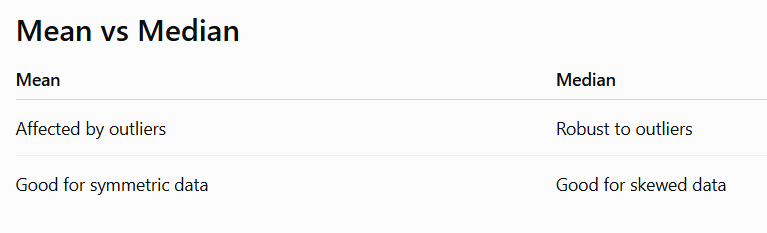

In [44]:
df["Gender"] = df["Gender"].fillna(
    df["Gender"].mode()[0]
)

When to Use forward fill?

Time-series data:

Stock prices
Sensor readings
Weather data

Not usually appropriate for unrelated rows.

In [46]:
# df["Price"] = df["Price"].ffill()

In [47]:
# df["Price"] = df["Price"].bfill()

In [49]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Name": ["Abid", "Sara", "John", "Mina", "David", "Emma"],
    "Gender": ["Male", "Female", "Male", "Female", "Male", "Female"],
    "Salary": [50000, 60000, np.nan, 65000, 55000, np.nan]
})

print(df)

    Name  Gender   Salary
0   Abid    Male  50000.0
1   Sara  Female  60000.0
2   John    Male      NaN
3   Mina  Female  65000.0
4  David    Male  55000.0
5   Emma  Female      NaN


In [50]:
print(df.groupby("Gender")["Salary"].mean())

Gender
Female    62500.0
Male      52500.0
Name: Salary, dtype: float64


In [51]:
# Method 7 — Group-wise Imputation ⭐⭐⭐⭐⭐
# Calculate the mean within each gender.
df["Salary"] = df["Salary"].fillna(
    df.groupby("Gender")["Salary"].transform("mean")
)

In [52]:
df

,Name,Gender,Salary
0,Abid,Male,50000.0
1,Sara,Female,60000.0
2,John,Male,52500.0
3,Mina,Female,65000.0
4,David,Male,55000.0
5,Emma,Female,62500.0


Method 8 — KNN Imputation

Suppose one student's age is missing.

Find the most similar students using other features.

Use their ages to estimate the missing value.

This is the idea behind KNN Imputation.

In [57]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
df = pd.DataFrame({
    "Name": [
        "Abid",
        "Sara",
        "John",
        "Mina",
        "David",
        "Emma"],
    "Age": [
        22,
        23,
        np.nan,
        24,
        22,
        23],
    "Study_Hours": [
        10,
        15,
        11,
        np.nan,
        9,
        16],
    "Marks": [
        85,
        92,
        84,
        90,
        np.nan,
        95]})
print(df)

    Name   Age  Study_Hours  Marks
0   Abid  22.0         10.0   85.0
1   Sara  23.0         15.0   92.0
2   John   NaN         11.0   84.0
3   Mina  24.0          NaN   90.0
4  David  22.0          9.0    NaN
5   Emma  23.0         16.0   95.0


In [ ]:
imputer = KNNImputer(n_neighbors=3) # "For every missing value, look at the 3 most similar rows."

numeric_cols = ["Age", "Study_Hours", "Marks"]

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
# Avoid it for very large datasets because it can be computationally expensive.

In [61]:
df

,Name,Age,Study_Hours,Marks
0,Abid,22.000000,10.000000,85.000000
1,Sara,23.000000,15.000000,92.000000
2,John,22.666667,11.000000,84.000000
3,Mina,24.000000,13.333333,90.000000
4,David,22.000000,9.000000,86.333333
5,Emma,23.000000,16.000000,95.000000


## Method 9 — Iterative Imputation (MICE)
Idea:

Predict one missing feature using all the other features. it says "Let's train a machine learning model to predict each missing value using the other columns."

Repeat this process several times until the estimates stabilize.

This is one of the most advanced imputation methods.

Example:

Predict Age using:

Marks
Study Hours
Gender (after encoding)
Attendance

Then predict another feature using the updated data.

In [64]:
import pandas as pd
import numpy as np

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Sample data
df = pd.DataFrame({
    "Age": [22, 23, np.nan, 24, 22, 23],
    "Study_Hours": [10, 15, 11, np.nan, 9, 16],
    "Marks": [85, 92, 84, 90, np.nan, 95]
})
print(df)

# Numeric columns
numeric_cols = ["Age", "Study_Hours", "Marks"]

# Create imputer
imputer = IterativeImputer(random_state=42)

# Impute missing values
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print(df)

    Age  Study_Hours  Marks
0  22.0         10.0   85.0
1  23.0         15.0   92.0
2   NaN         11.0   84.0
3  24.0          NaN   90.0
4  22.0          9.0    NaN
5  23.0         16.0   95.0
         Age  Study_Hours      Marks
0  22.000000    10.000000  85.000000
1  23.000000    15.000000  92.000000
2  22.483194    11.000000  84.000000
3  24.000000    17.084133  90.000000
4  22.000000     9.000000  81.925171
5  23.000000    16.000000  95.000000


In [65]:
# exercise
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Gender": ["Male", "Male", "Female", "Female", "Male", "Female"],
    "Salary": [50000, np.nan, 35000, np.nan, 55000, 40000]
})

print(df)
overall_mean = df["Salary"].mean()

print(overall_mean)
df["Salary"] = df["Salary"].fillna(overall_mean)

print(df)

   Gender   Salary
0    Male  50000.0
1    Male      NaN
2  Female  35000.0
3  Female      NaN
4    Male  55000.0
5  Female  40000.0
45000.0
   Gender   Salary
0    Male  50000.0
1    Male  45000.0
2  Female  35000.0
3  Female  45000.0
4    Male  55000.0
5  Female  40000.0


In [66]:
df = pd.DataFrame({
    "Gender": ["Male", "Male", "Female", "Female", "Male", "Female"],
    "Salary": [50000, np.nan, 35000, np.nan, 55000, 40000]
})
df["Salary"] = df["Salary"].fillna(
    df.groupby("Gender")["Salary"].transform("mean")
)

print(df)

   Gender   Salary
0    Male  50000.0
1    Male  52500.0
2  Female  35000.0
3  Female  37500.0
4    Male  55000.0
5  Female  40000.0


## Lesson 4 — Encoding Categorical Variables (Industry-Level Mastery)


## Label Encoding:
Advantages:  ✔ Very fast, ✔ Easy, ✔ Low memory

Disadvantages:  The model may think 2 > 1 > 0

which implies an order.

That is incorrect for nominal categories.
When Should We Use Label Encoding?

Good for: Binary categories

Example Male/Female, Yes/No, True/False

Also suitable for many tree-based models (Decision Trees, Random Forests, Gradient Boosting), because they don't interpret the numeric codes as distances.

Avoid using it for multi-class nominal variables with algorithms that rely on distances or linear relationships.

In [1]:
import pandas as pd

df = pd.DataFrame({

    "Gender":[
        "Male",
        "Female",
        "Female",
        "Male",
        "Female"
    ],

    "Department":[
        "IT",
        "HR",
        "Finance",
        "IT",
        "HR"
    ],

    "Education":[
        "Bachelor",
        "Master",
        "PhD",
        "Bachelor",
        "Secondary"
    ],

    "Salary":[
        50000,
        70000,
        90000,
        52000,
        45000
    ]

})

print(df)

   Gender Department  Education  Salary
0    Male         IT   Bachelor   50000
1  Female         HR     Master   70000
2  Female    Finance        PhD   90000
3    Male         IT   Bachelor   52000
4  Female         HR  Secondary   45000


In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

In [3]:
df

,Gender,Department,Education,Salary
0,1,IT,Bachelor,50000
1,0,HR,Master,70000
2,0,Finance,PhD,90000
3,1,IT,Bachelor,52000
4,0,HR,Secondary,45000


In [4]:
print(dict(zip(
    le.classes_,
    le.transform(le.classes_)
)))

{'Female': np.int64(0), 'Male': np.int64(1)}


## Method 2 — One-Hot Encoding ⭐⭐⭐⭐⭐
Advantages

✔ No false ordering

✔ Widely accepted

✔ Works with many algorithms
Disadvantages

If there are thousands of categories:

5000 Cities

↓

5000 columns

Memory usage increases dramatically.

In [5]:
pd.get_dummies(
    df,
    columns=["Department"]
)

,Gender,Education,Salary,Department_Finance,Department_HR,Department_IT
0,1,Bachelor,50000,False,False,True
1,0,Master,70000,False,True,False
2,0,PhD,90000,True,False,False
3,1,Bachelor,52000,False,False,True
4,0,Secondary,45000,False,True,False


In [6]:
# Removes one dummy column.Useful for many linear models to avoid perfect multicollinearity (often called the "dummy variable trap").
pd.get_dummies(
    df,
    columns=["Department"],
    drop_first=True
)

,Gender,Education,Salary,Department_HR,Department_IT
0,1,Bachelor,50000,False,True
1,0,Master,70000,True,False
2,0,PhD,90000,False,False
3,1,Bachelor,52000,False,True
4,0,Secondary,45000,True,False


## Method 3 — Ordinal Encoding
Secondary → 0, Bachelor → 1, Master → 2, PhD → 3

In [7]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(
    categories=[
        [
            "Secondary",
            "Bachelor",
            "Master",
            "PhD"
        ]
    ]
)

df["Education"] = oe.fit_transform(
    df[["Education"]]
)

In [8]:
df

,Gender,Department,Education,Salary
0,1,IT,1.0,50000
1,0,HR,2.0,70000
2,0,Finance,3.0,90000
3,1,IT,1.0,52000
4,0,HR,0.0,45000


## Method 4 — Frequency Encoding
IT → 3

HR → 1

Finance → 1

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Employee": [
        "Abid",
        "Sara",
        "John",
        "Mina",
        "David",
        "Emma",
        "Alex",
        "Tom"
    ],

    "Department": [
        "IT",
        "HR",
        "IT",
        "Finance",
        "IT",
        "HR",
        "Finance",
        "IT"
    ]
})

print(df)

  Employee Department
0     Abid         IT
1     Sara         HR
2     John         IT
3     Mina    Finance
4    David         IT
5     Emma         HR
6     Alex    Finance
7      Tom         IT


In [ ]:
# Useful when there are many categories.
freq = df["Department"].value_counts()

df["Department"] = df["Department"].map(freq)

In [11]:
df

,Employee,Department
0,Abid,4
1,Sara,2
2,John,4
3,Mina,2
4,David,4
5,Emma,2
6,Alex,2
7,Tom,4


## Method 5 — Target Encoding
Replace a category with the average value of the target variable for that category.

## Method 6 — Binary Encoding
Assign number then convert to binary


In [12]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Create DataFrame
df = pd.DataFrame({
    "Gender": ["Male", "Female", "Male", "Female", "Male"]
})

print("Original DataFrame")
print(df)

# Create encoder
encoder = LabelEncoder()

# Encode
df["Gender"] = encoder.fit_transform(df["Gender"])

print("\nEncoded DataFrame")
print(df)

# Display mapping
mapping = dict(zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
))

print("\nMapping")
print(mapping)

Original DataFrame
   Gender
0    Male
1  Female
2    Male
3  Female
4    Male

Encoded DataFrame
   Gender
0       1
1       0
2       1
3       0
4       1

Mapping
{'Female': np.int64(0), 'Male': np.int64(1)}


In [13]:
import pandas as pd

# Create DataFrame
df = pd.DataFrame({
    "Department": ["IT", "HR", "Finance", "IT", "HR"]
})

print("Original DataFrame")
print(df)

# One-Hot Encoding
print("\nOne-Hot Encoding")
df_dummies = pd.get_dummies(df["Department"])
print(df_dummies)

# One-Hot Encoding with drop_first=True
print("\nOne-Hot Encoding (drop_first=True)")
df_drop = pd.get_dummies(
    df["Department"],
    drop_first=True
)
print(df_drop)

Original DataFrame
  Department
0         IT
1         HR
2    Finance
3         IT
4         HR

One-Hot Encoding
   Finance     HR     IT
0    False  False   True
1    False   True  False
2     True  False  False
3    False  False   True
4    False   True  False

One-Hot Encoding (drop_first=True)
      HR     IT
0  False   True
1   True  False
2  False  False
3  False   True
4   True  False


In [14]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# Create DataFrame
df = pd.DataFrame({
    "Education": [
        "Secondary",
        "Bachelor",
        "Master",
        "PhD",
        "Bachelor"
    ]
})

print("Original DataFrame")
print(df)

# Define the order
education_order = [
    ["Secondary", "Bachelor", "Master", "PhD"]
]

# Create encoder
encoder = OrdinalEncoder(
    categories=education_order
)

# Encode
df["Education"] = encoder.fit_transform(
    df[["Education"]]
)

print("\nEncoded DataFrame")
print(df)

Original DataFrame
   Education
0  Secondary
1   Bachelor
2     Master
3        PhD
4   Bachelor

Encoded DataFrame
   Education
0        0.0
1        1.0
2        2.0
3        3.0
4        1.0


## Lesson 5 — Feature Scaling (Industry-Level Mastery)
Feature Scaling is the process of transforming numerical features so they have comparable scales.
Notice:

Scaling changes the numbers.

It does not change the meaning of the data.

In [15]:
import pandas as pd

df = pd.DataFrame({

    "Age":[
        20,22,25,28,30
    ],

    "Salary":[
        25000,
        30000,
        50000,
        70000,
        100000
    ]
})

print(df)

   Age  Salary
0   20   25000
1   22   30000
2   25   50000
3   28   70000
4   30  100000


## Method 1 — StandardScaler ⭐⭐⭐⭐⭐
This is the most commonly used scaler.
Transform data so that: Mean = 0, Standard Deviation = 1
Excellent for: Logistic Regression, Linear Regression,SVM, PCA, Neural Networks, K-Means
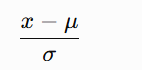

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["Age","Salary"]] = scaler.fit_transform(
    df[["Age","Salary"]]
)

print(df)

        Age    Salary
0 -1.355815 -1.088214
1 -0.813489 -0.906845
2  0.000000 -0.181369
3  0.813489  0.544107
4  1.355815  1.632322


## Method 2 — MinMaxScaler
Instead of making mean = 0,
MinMaxScaler converts values to a fixed range. usually 0-1
When to Use?

Very common for:

Neural Networks
Deep Learning
Image Processing

Works well when you want all values in the same bounded range.
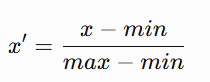

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["Age","Salary"]] = scaler.fit_transform(
    df[["Age","Salary"]]
)

In [19]:
df

,Age,Salary
0,0.0,0.000000
1,0.2,0.066667
2,0.5,0.333333
3,0.8,0.600000
4,1.0,1.000000


## Method 3 — RobustScaler ⭐⭐⭐⭐⭐
One of the best scalers for data containing outliers.
It uses: Median, Interquartile Range (IQR)
Whenever your data contains many outliers.

Examples:

Salary
House prices
Medical expenses
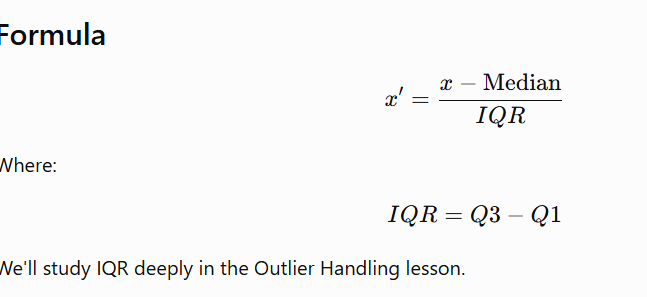

In [20]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

df[["Age","Salary"]] = scaler.fit_transform(
    df[["Age","Salary"]]
)

In [21]:
df

,Age,Salary
0,-0.833333,-0.625
1,-0.500000,-0.500
2,0.000000,0.000
3,0.500000,0.500
4,0.833333,1.250


## Method 4 — MaxAbsScaler
Divide everything by the maximum absolute value.
Useful when working with sparse data (many zeros), such as text data represented with bag-of-words or TF-IDF features.

It preserves zeros instead of shifting the data.


In [22]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()

df[["Age","Salary"]] = scaler.fit_transform(
    df[["Age","Salary"]]
)

In [23]:
df

,Age,Salary
0,-1.0,-0.5
1,-0.6,-0.4
2,0.0,0.0
3,0.6,0.4
4,1.0,1.0


## Method 5 — Normalizer
This is often confused with MinMaxScaler. They are not the same.
Scalers work column-wise. Normalizer works row-wise.
Normalizer rescales the entire row so that its length (norm) becomes 1.
It is commonly used when the direction of the feature vector matters more than its magnitude


In [24]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer()

df[["Age","Salary"]] = normalizer.fit_transform(
    df[["Age","Salary"]]
)


In [25]:
df

,Age,Salary
0,-0.894427,-0.447214
1,-0.832050,-0.554700
2,0.000000,0.000000
3,0.832050,0.554700
4,0.707107,0.707107


Which Algorithms Need Scaling?
Scaling Required ✅
K-Nearest Neighbors (KNN)
K-Means
Support Vector Machine (SVM)
Logistic Regression
Linear Regression (often improves optimization)
Neural Networks
Principal Component Analysis (PCA)

These algorithms use:

Distance
Gradient optimization
Magnitude

Scaling helps them work correctly and converge faster.

Which Algorithms Usually Don't Need Scaling?
Decision Tree
Random Forest
XGBoost
LightGBM
CatBoost

These models split data based on thresholds rather than distances, so feature scales generally don't matter.
Split

↓

Fit scaler on training data

↓

Transform training data

↓

Transform test data

In [26]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Create DataFrame
df = pd.DataFrame({
    "Age": [20, 22, 25, 28, 30],
    "Salary": [25000, 30000, 50000, 70000, 100000]
})

print("Original DataFrame")
print(df)

# Create StandardScaler object
scaler = StandardScaler()

# Scale the data
scaled_data = scaler.fit_transform(df)

# Convert back to DataFrame
scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

print("\nScaled DataFrame")
print(scaled_df)

# Verify the mean
print("\nMean of Each Column")
print(scaled_df.mean())

Original DataFrame
   Age  Salary
0   20   25000
1   22   30000
2   25   50000
3   28   70000
4   30  100000

Scaled DataFrame
        Age    Salary
0 -1.355815 -1.088214
1 -0.813489 -0.906845
2  0.000000 -0.181369
3  0.813489  0.544107
4  1.355815  1.632322

Mean of Each Column
Age       4.440892e-17
Salary    0.000000e+00
dtype: float64


In [27]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Create DataFrame
df = pd.DataFrame({
    "Age": [20, 22, 25, 28, 30],
    "Salary": [25000, 30000, 50000, 70000, 100000]
})

print("Original DataFrame")
print(df)

# Create scaler
scaler = MinMaxScaler()

# Scale data
scaled_data = scaler.fit_transform(df)

# Convert to DataFrame
scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

print("\nScaled DataFrame")
print(scaled_df)

# Check minimum values
print("\nMinimum Values")
print(scaled_df.min())

# Check maximum values
print("\nMaximum Values")
print(scaled_df.max())

Original DataFrame
   Age  Salary
0   20   25000
1   22   30000
2   25   50000
3   28   70000
4   30  100000

Scaled DataFrame
   Age    Salary
0  0.0  0.000000
1  0.2  0.066667
2  0.5  0.333333
3  0.8  0.600000
4  1.0  1.000000

Minimum Values
Age       0.0
Salary    0.0
dtype: float64

Maximum Values
Age       1.0
Salary    1.0
dtype: float64


In [28]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, RobustScaler

# Create DataFrame
df = pd.DataFrame({
    "Salary": [30000, 35000, 40000, 42000, 1000000]
})

print("Original DataFrame")
print(df)

# StandardScaler
standard_scaler = StandardScaler()
df["Salary_Standard"] = standard_scaler.fit_transform(
    df[["Salary"]]
)

# RobustScaler
robust_scaler = RobustScaler()
df["Salary_Robust"] = robust_scaler.fit_transform(
    df[["Salary"]]
)

print("\nScaled DataFrame")
print(df)

Original DataFrame
    Salary
0    30000
1    35000
2    40000
3    42000
4  1000000

Scaled DataFrame
    Salary  Salary_Standard  Salary_Robust
0    30000        -0.517489      -1.428571
1    35000        -0.504512      -0.714286
2    40000        -0.491536       0.000000
3    42000        -0.486346       0.285714
4  1000000         1.999883     137.142857


## Lesson 6 — Outlier Handling (Industry-Level Mastery)
Algorithms Affected by Outliers

Highly affected:

Linear Regression
Logistic Regression
KNN
K-Means
SVM
PCA

Less affected:

Decision Trees
Random Forest
XGBoost
LightGBM

Tree-based models split data based on thresholds rather than distances, making them much more robust to outliers.


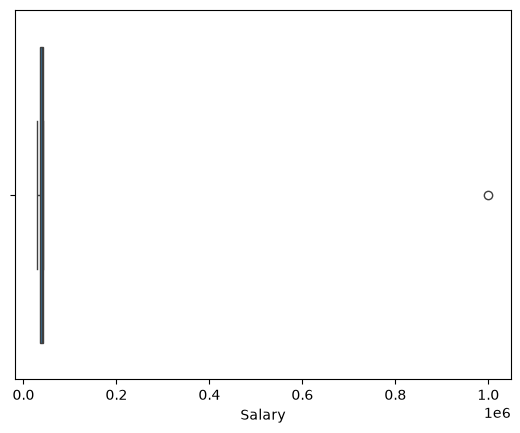

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["Salary"])

plt.show()

<Axes: ylabel='Frequency'>

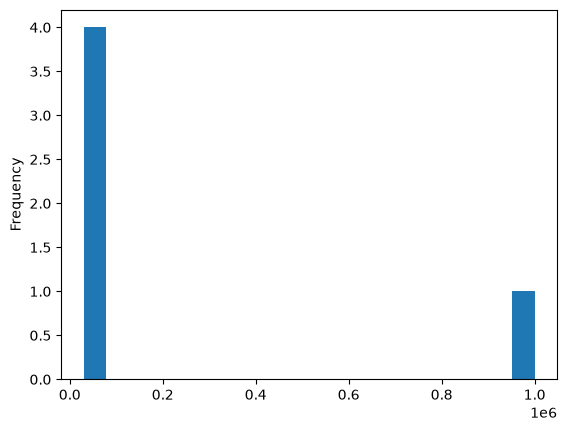

In [30]:
df["Salary"].plot(kind="hist", bins=20)

In [31]:
#Method 1 — IQR (Interquartile Range) ⭐⭐⭐⭐⭐
Q1 = df["Salary"].quantile(0.25)

Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Salary"] < lower) |
    (df["Salary"] > upper)
]

print(outliers)

    Salary  Salary_Standard  Salary_Robust
4  1000000         1.999883     137.142857


In [32]:
# Method 2 — Z-Score ⭐⭐⭐⭐
from scipy.stats import zscore

df["z"] = zscore(df["Salary"])

outliers = df[df["z"].abs() > 3]

print(outliers)

Empty DataFrame
Columns: [Salary, Salary_Standard, Salary_Robust, z]
Index: []


In [33]:
# Option 1 — Remove Outliers
df = df[
    (df["Salary"] >= lower) &
    (df["Salary"] <= upper)
]

In [ ]:
# Option 2 — Winsorization ⭐⭐⭐⭐
# Instead of deleting outliers, replace them with the boundary values.
from scipy.stats.mstats import winsorize

df["Salary"] = winsorize(
    df["Salary"],
    limits=[0.05, 0.05]
)

In [35]:
df

,Salary,Salary_Standard,Salary_Robust,z
0,30000,-0.517489,-1.428571,-0.517489
1,35000,-0.504512,-0.714286,-0.504512
2,40000,-0.491536,0.000000,-0.491536
3,42000,-0.486346,0.285714,-0.486346


In [36]:
# Option 3 — Clipping: replace outliers with the boundary values using numpy's clip function.
df["Salary"] = df["Salary"].clip(
    lower=30000,
    upper=100000
)

In [37]:
df

,Salary,Salary_Standard,Salary_Robust,z
0,30000,-0.517489,-1.428571,-0.517489
1,35000,-0.504512,-0.714286,-0.504512
2,40000,-0.491536,0.000000,-0.491536
3,42000,-0.486346,0.285714,-0.486346


In [ ]:
#  Option 4 — Log Transformation ⭐⭐⭐⭐⭐
"""When Should We Use Log Transformation?

Useful when:

Values are positive.
Data is heavily right-skewed.
Large values dominate the distribution.

Do not apply np.log() directly to zero or negative values."""
import numpy as np

df["Salary"] = np.log(df["Salary"])

In [39]:
df

,Salary,Salary_Standard,Salary_Robust,z
0,10.308953,-0.517489,-1.428571,-0.517489
1,10.463103,-0.504512,-0.714286,-0.504512
2,10.596635,-0.491536,0.000000,-0.491536
3,10.645425,-0.486346,0.285714,-0.486346


## Lesson 7 — Feature Engineering (Industry-Level Mastery)
Congratulations! 🎉

You have now reached the stage that separates beginners from good data scientists.

Most beginners think:

"The machine learning algorithm is the most important part."

Professional ML engineers know:

Better features usually improve a model more than changing the algorithm.

A simple model with excellent features often outperforms a complex model with poor features.
Types of Feature Engineering:
Feature Engineering

│

├── Numerical Features

├── Date & Time Features

├── Interaction Features

├── Polynomial Features

├── Aggregation Features

├── Text Features

└── Domain Knowledge Features


Raw Data
     │
     ▼
Data Cleaning
     │
     ▼
Missing Values
     │
     ▼
Encoding
     │
     ▼
Scaling
     │
     ▼
Outlier Handling
     │
     ▼
⭐ Feature Engineering ⭐
     │
     ▼
Better Dataset
     │
     ▼
Machine Learning Model

In [49]:
import pandas as pd

df = pd.DataFrame({

    "Study_Hours":[
        5,8,10,12,15
    ],

    "Attendance":[
        80,90,95,85,100
    ],

    "Marks":[
        60,72,80,84,95
    ]

})

print(df)

   Study_Hours  Attendance  Marks
0            5          80     60
1            8          90     72
2           10          95     80
3           12          85     84
4           15         100     95


## Method 1 — Creating Numerical Features ⭐⭐⭐⭐⭐

This is the easiest type.

Suppose we believe:

Students who study more and attend more classes perform better.

In [42]:
# Total Efort
df["Total_Effort"] = (
    df["Study_Hours"] +
    df["Attendance"]
)
df

,Study_Hours,Attendance,Marks,Total_Effort
0,5,80,60,85
1,8,90,72,98
2,10,95,80,105
3,12,85,84,97
4,15,100,95,115


In [ ]:
"""## Method 2 — Ratio Features ⭐⭐⭐⭐⭐

Ratios are extremely common in industry.
This tells us how efficiently a student studies.
"""
df["Marks_per_Hour"] = (
    df["Marks"] /
    df["Study_Hours"]
)
df

,Study_Hours,Attendance,Marks,Total_Effort,Marks_per_Hour
0,5,80,60,85,12.000000
1,8,90,72,98,9.000000
2,10,95,80,105,8.000000
3,12,85,84,97,7.000000
4,15,100,95,115,6.333333


In [47]:
import pandas as pd

df = pd.DataFrame({
    "Purchase_Date": [
        "2026-01-10",
        "2026-02-15",
        "2026-08-01"
    ]
})

# Convert to datetime
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"])

# Extract date features
df["Year"] = df["Purchase_Date"].dt.year
df["Month"] = df["Purchase_Date"].dt.month
df["Day"] = df["Purchase_Date"].dt.day
df["Day_Name"] = df["Purchase_Date"].dt.day_name()
df["Weekend"] = df["Purchase_Date"].dt.dayofweek >= 5

print(df)

  Purchase_Date  Year  Month  Day  Day_Name  Weekend
0    2026-01-10  2026      1   10  Saturday     True
1    2026-02-15  2026      2   15    Sunday     True
2    2026-08-01  2026      8    1  Saturday     True


In [50]:
"""Method 4 — Interaction Features ⭐⭐⭐⭐⭐

Interaction means combining two features."""
df["Study_Attendance"] = (
    df["Study_Hours"] *
    df["Attendance"]
)
df

,Study_Hours,Attendance,Marks,Study_Attendance
0,5,80,60,400
1,8,90,72,720
2,10,95,80,950
3,12,85,84,1020
4,15,100,95,1500


In [ ]:
"""Sometimes relationships are curved instead of straight.

Example:

Plant growth.

More water helps.

Too much water hurts.

This is not a straight-line relationship.
If multiple columns are used, PolynomialFeatures also creates interaction terms automatically."""
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

new_features = poly.fit_transform(
    df[["Study_Hours"]]
)
df

,Study_Hours,Attendance,Marks,Study_Attendance
0,5,80,60,400
1,8,90,72,720
2,10,95,80,950
3,12,85,84,1020
4,15,100,95,1500


In [54]:
import pandas as pd

# Create DataFrame
df = pd.DataFrame({
    "Employee": [
        "Abid", "Sara", "John",
        "Mina", "Alex", "Emma"
    ],
    "Department": [
        "IT", "IT", "HR",
        "HR", "Finance", "Finance"
    ],
    "Salary": [
        50000, 60000,
        45000, 55000,
        70000, 90000
    ]
})

print("Original DataFrame")
print(df)

# Create aggregation feature
df["Dept_Avg_Salary"] = (
    df.groupby("Department")["Salary"]
      .transform("mean")
)

print("\nAfter Feature Engineering")
print(df)

Original DataFrame
  Employee Department  Salary
0     Abid         IT   50000
1     Sara         IT   60000
2     John         HR   45000
3     Mina         HR   55000
4     Alex    Finance   70000
5     Emma    Finance   90000

After Feature Engineering
  Employee Department  Salary  Dept_Avg_Salary
0     Abid         IT   50000          55000.0
1     Sara         IT   60000          55000.0
2     John         HR   45000          50000.0
3     Mina         HR   55000          50000.0
4     Alex    Finance   70000          80000.0
5     Emma    Finance   90000          80000.0


In [ ]:
# Method 7 — Text Features
# This is a common Text Feature Engineering technique used in Natural Language Processing (NLP).

#The goal is to create new numerical features from text that machine learning models can use.
import pandas as pd

# Create DataFrame
df = pd.DataFrame({
    "Review": [
        "This product is amazing",
        "Very bad quality",
        "I love this phone",
        "Not worth the money",
        "Excellent!"
    ]
})

print("Original DataFrame")
print(df)

# ===============================
# Feature Engineering
# ===============================

# Count the number of words
df["Word_Count"] = (
    df["Review"]
      .str.split()
      .str.len()
)

# Count the number of characters
df["Characters"] = (
    df["Review"]
      .str.len()
)

print("\nDataFrame After Feature Engineering")
print(df)

Original DataFrame
                    Review
0  This product is amazing
1         Very bad quality
2        I love this phone
3      Not worth the money
4               Excellent!

DataFrame After Feature Engineering
                    Review  Word_Count  Characters
0  This product is amazing           4          23
1         Very bad quality           3          16
2        I love this phone           4          17
3      Not worth the money           4          19
4               Excellent!           1          10


In [ ]:
# Method 8 — Domain Knowledge ⭐⭐⭐⭐⭐

## Lesson 8 — Feature Selection (Industry-Level Mastery)
Congratulations! 🎉

You've learned how to create new features.

Now comes another extremely important question.

Should we use every feature?

The answer is:

No.

Professional data scientists spend a lot of time removing unnecessary features.

Why?

Because more features do not always produce a better model.
Feature Selection means:

Choosing the most useful features while removing unnecessary ones.
Removing the rest often:

improves accuracy
reduces overfitting
speeds up training
makes models easier to explain
Types of Feature Selection:
Feature Selection

│

├── Filter Methods

├── Wrapper Methods

└── Embedded Methods

Raw Data
    │
    ▼
Data Understanding
    │
    ▼
Data Cleaning
    │
    ▼
Missing Values
    │
    ▼
Encoding
    │
    ▼
Feature Scaling
    │
    ▼
Outlier Handling
    │
    ▼
Feature Engineering
    │
    ▼
Feature Selection
    │
    ▼
Data Transformation
    │
    ▼
Train/Test Split
    │
    ▼
Pipeline
    │
    ▼
Machine Learning Model
    │
    ▼
Evaluation
    │
    ▼
Deployment

In [61]:
"""Filter Methods ⭐⭐⭐⭐⭐

Filter methods select features before training the model.

They rely on statistical measures rather than a specific machine learning algorithm."""
# Method 1 — Correlation
"""As study hours increase,

marks also increase.

Strong positive correlation."""
import pandas as pd

import pandas as pd

df = pd.DataFrame({
    "Student_ID": [101,102,103,104,105,106,107,108,109,110],

    "Age": [20,21,22,20,23,21,24,22,20,23],

    "Study_Hours": [4,6,5,8,10,7,3,9,6,11],

    "Attendance": [75,82,78,90,96,88,72,94,80,98],

    "Assignments": [60,72,68,85,95,82,58,90,70,98],

    "Marks": [55,68,63,82,95,78,50,90,70,98]
})

print(df)

corr = df.corr(numeric_only=True)

print(corr)

   Student_ID  Age  Study_Hours  Attendance  Assignments  Marks
0         101   20            4          75           60     55
1         102   21            6          82           72     68
2         103   22            5          78           68     63
3         104   20            8          90           85     82
4         105   23           10          96           95     95
5         106   21            7          88           82     78
6         107   24            3          72           58     50
7         108   22            9          94           90     90
8         109   20            6          80           70     70
9         110   23           11          98           98     98
             Student_ID       Age  Study_Hours  Attendance  Assignments  \
Student_ID     1.000000  0.384995     0.458509    0.422412     0.443685   
Age            0.384995  1.000000     0.167290    0.162781     0.197730   
Study_Hours    0.458509  0.167290     1.000000    0.989354     0.990183

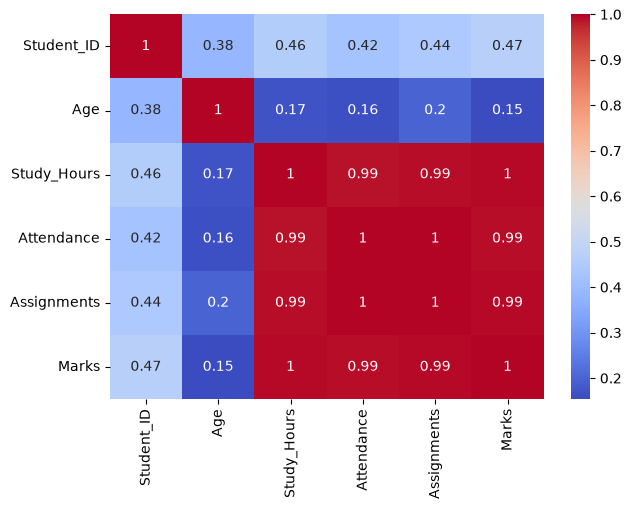

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [63]:
# Method 2 — Variance Threshold ⭐⭐⭐⭐
# If a feature barely changes,

# it usually cannot distinguish one sample from another.
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(
    threshold=0
)

X = df.drop(columns=["Marks"])

X_new = selector.fit_transform(X)

print(X_new)

[[101  20   4  75  60]
 [102  21   6  82  72]
 [103  22   5  78  68]
 [104  20   8  90  85]
 [105  23  10  96  95]
 [106  21   7  88  82]
 [107  24   3  72  58]
 [108  22   9  94  90]
 [109  20   6  80  70]
 [110  23  11  98  98]]


In [64]:
"""Method 3 — Mutual Information ⭐⭐⭐⭐⭐

Correlation detects linear relationships.

Mutual Information (MI) detects:

Linear relationships
Nonlinear relationships

Think of it as measuring how much knowing one variable reduces uncertainty about another."""
from sklearn.feature_selection import mutual_info_regression

X = df.drop(columns=["Marks"])
y = df["Marks"]

mi = mutual_info_regression(X, y)

print(mi)

[0.02801587 0.17230159 0.94563492 0.81230159 0.81230159]


In [65]:
"""Wrapper Methods ⭐⭐⭐⭐⭐

Wrapper methods actually train a model and evaluate different subsets of features.

They are usually more accurate but slower.

Recursive Feature Elimination (RFE)

One of the most popular wrapper methods.

Idea

Suppose we have:

Age

Salary

Study Hours

Attendance

ID

Train model.

Find least useful feature.

Remove it.

Train again.

Repeat until only the desired number of features remains."""
from sklearn.feature_selection import RFE

from sklearn.linear_model import LinearRegression

X = df.drop(columns=["Marks"])
y = df["Marks"]

model = LinearRegression()

selector = RFE(
    estimator=model,
    n_features_to_select=3
)

selector.fit(X, y)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LinearRegression()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",3
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
estimator_ estimator_: ``Estimator`` instanceThe fitted estimator used to select features.,LinearRegression,LinearRegression()
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Student_ID','Age','Study_Hours','Attendance','Assignments']"
n_features_ n_features_: intThe number of selected features.,int64,np.int64(3)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,5
"ranking_ ranking_: ndarray of shape (n_features,)The feature ranking, such that ``ranking_[i]`` corresponds to theranking position of the i-th feature. Selected (i.e., estimatedbest) features are assigned rank 1.","ndarray[int64](5,)","[2,1,1,3,1]"


In [66]:
"""Embedded Methods ⭐⭐⭐⭐⭐

These methods perform feature selection while training the model.

Unlike filter methods (before training) and wrapper methods (repeated training), embedded methods build feature selection directly into the learning algorithm.

Decision Tree Feature Importance

Tree models naturally estimate how useful each feature is."""
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=["Marks"])
y = df["Marks"]

model = RandomForestRegressor(
    random_state=42
)

model.fit(X, y)

print(model.feature_importances_)

[0.03142194 0.04276782 0.25277453 0.32416245 0.34887327]


# Lesson 9 — Data Transformation (Industry-Level Mastery)

Congratulations! 🎉

You've now reached one of the most important topics in machine learning preprocessing.

Many beginners ask:

"Why transform the data if the values are already correct?"

This is an excellent question.

The answer is:

Machine learning algorithms often learn better when data has a more suitable distribution.

Data transformation doesn't change the meaning of your data—it changes its representation to make patterns easier for models to learn.
Data Transformation means:

Changing the mathematical representation of a feature without changing its underlying meaning.
Why Transform Data?

Many ML algorithms assume data follows a roughly normal (bell-shaped) distribution.

Examples:

Linear Regression
Logistic Regression
PCA
Naive Bayes (certain variants)
Linear Discriminant Analysis

If data is heavily skewed,

the model may struggle.
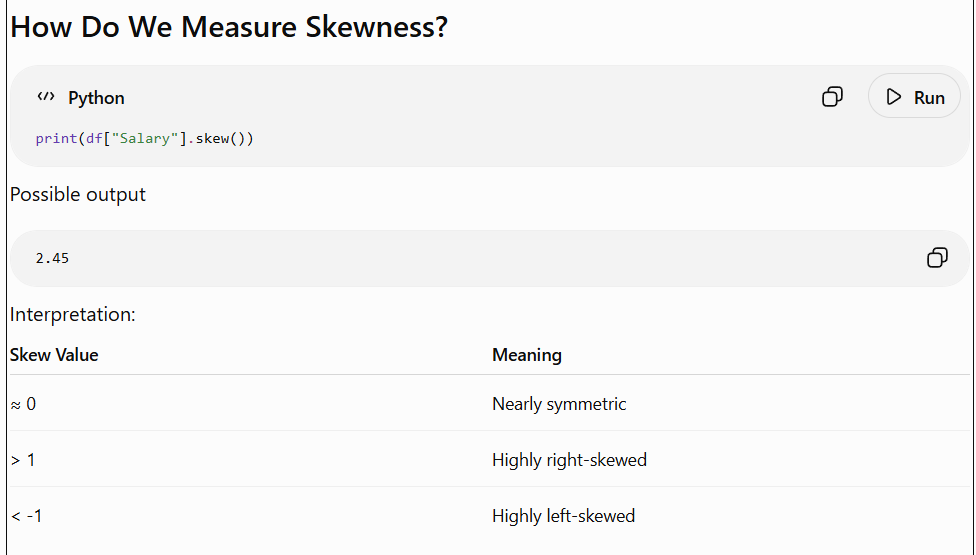

In [69]:
"""Method 1 — Log Transformation ⭐⭐⭐⭐⭐

The most commonly used transformation.

When Should We Use It?

Use when

Values are positive
Distribution is right-skewed
Large values dominate"""
import pandas as pd

df = pd.DataFrame({

    "Salary":[
        30000,
        35000,
        40000,
        50000,
        1000000
    ]

})
df

,Salary
0,30000
1,35000
2,40000
3,50000
4,1000000


In [71]:
import numpy as np

df["Salary_Log"] = np.log(df["Salary"])
df

,Salary,Salary_Log
0,30000,10.308953
1,35000,10.463103
2,40000,10.596635
3,50000,10.819778
4,1000000,13.815511


In [ ]:
"""Method 2 — Square Root Transformation ⭐⭐⭐⭐

Less aggressive than log transformation.

Useful for:

Moderate skewness
Count data
Log compresses large values more strongly than square root."""
df = pd.DataFrame({

    "Orders":[
        1,
        4,
        9,
        16,
        100
    ]

})
import numpy as np

df["Orders_Sqrt"] = np.sqrt(df["Orders"])
df

,Orders,Orders_Sqrt
0,1,1.0
1,4,2.0
2,9,3.0
3,16,4.0
4,100,10.0


Original DataFrame
   Salary
0   30000
1   35000
2   40000
3   45000
4   50000
5   60000
6   70000
7   80000
8  120000
9  500000

Transformed DataFrame
   Salary  Salary_BoxCox
0   30000       1.124058
1   35000       1.124073
2   40000       1.124085
3   45000       1.124094
4   50000       1.124101
5   60000       1.124112
6   70000       1.124120
7   80000       1.124126
8  120000       1.124141
9  500000       1.124166

Optimal Lambda: -0.8895410470699151


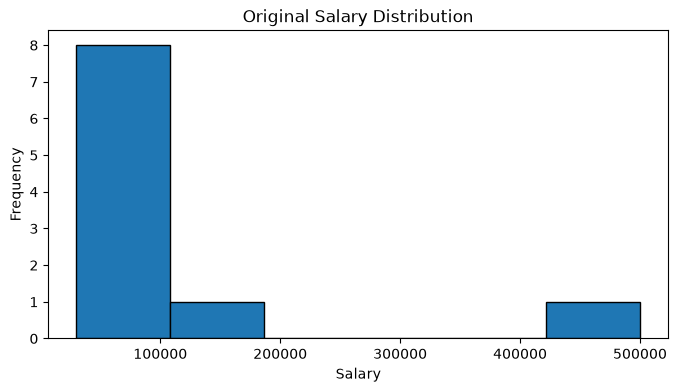

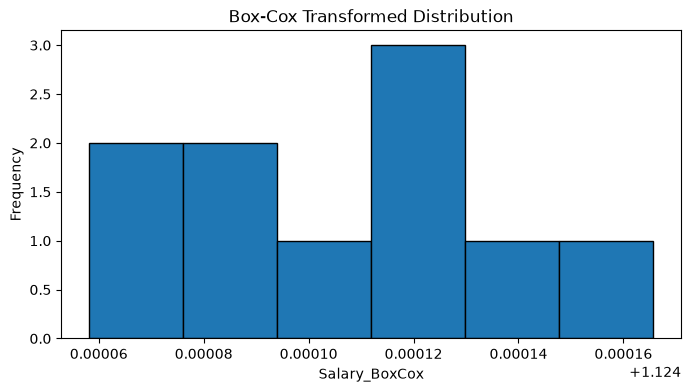

In [74]:
"""Method 3 — Box-Cox Transformation ⭐⭐⭐⭐⭐

One of the most powerful transformations.

Requirement

All values must be

Strictly positive

No zero.

No negative values
What is lam?

lam (lambda) is the transformation parameter that Box-Cox chooses automatically.

Why Use Box-Cox?

Instead of guessing

Log?

Square Root?

Cube Root?

Box-Cox tries many possibilities and selects the one that best normalizes the data."""
from scipy.stats import boxcox

import pandas as pd
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Create DataFrame
df = pd.DataFrame({
    "Salary": [
        30000,
        35000,
        40000,
        45000,
        50000,
        60000,
        70000,
        80000,
        120000,
        500000
    ]
})

print("Original DataFrame")
print(df)

# Apply Box-Cox Transformation
df["Salary_BoxCox"], lam = boxcox(df["Salary"])

print("\nTransformed DataFrame")
print(df)

print("\nOptimal Lambda:", lam)

# Plot Original Distribution
plt.figure(figsize=(8,4))
plt.hist(df["Salary"], bins=6, edgecolor="black")
plt.title("Original Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

# Plot Box-Cox Distribution
plt.figure(figsize=(8,4))
plt.hist(df["Salary_BoxCox"], bins=6, edgecolor="black")
plt.title("Box-Cox Transformed Distribution")
plt.xlabel("Salary_BoxCox")
plt.ylabel("Frequency")
plt.show()


Original DataFrame
   Salary
0   -5000
1       0
2   25000
3   30000
4   40000
5   45000
6   50000
7   60000
8   70000
9  500000

Transformed DataFrame
   Salary  Salary_Transformed
0   -5000           -1.697689
1       0           -0.496320
2   25000           -0.225794
3   30000           -0.182532
4   40000           -0.099778
5   45000           -0.059897
6   50000           -0.020836
7   60000            0.055194
8   70000            0.128886
9  500000            2.598766


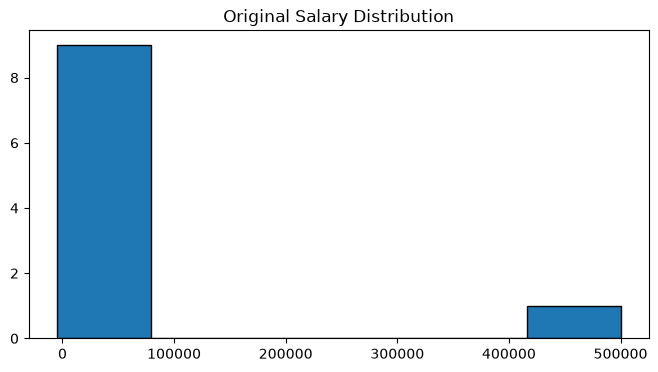

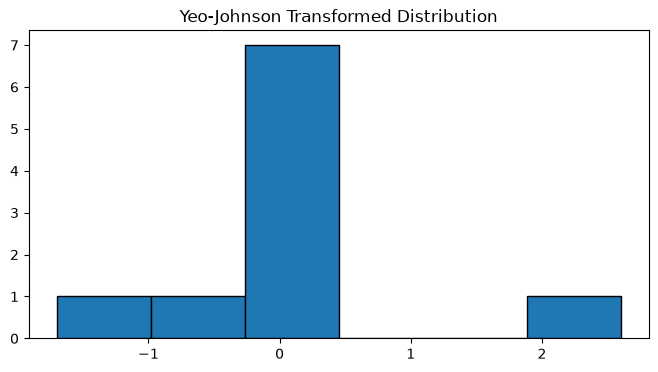

In [75]:
"""Method 4 — Yeo-Johnson ⭐⭐⭐⭐⭐

Think of Yeo-Johnson as an improved Box-Cox.

It can transform

Positive values ✅
Zero values ✅
Negative values ✅"""
import pandas as pd
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt

# Create DataFrame
df = pd.DataFrame({
    "Salary": [
        -5000,
        0,
        25000,
        30000,
        40000,
        45000,
        50000,
        60000,
        70000,
        500000
    ]
})

print("Original DataFrame")
print(df)

# Create transformer
pt = PowerTransformer(method="yeo-johnson")

# Transform Salary
df["Salary_Transformed"] = pt.fit_transform(df[["Salary"]])

print("\nTransformed DataFrame")
print(df)

# Plot original distribution
plt.figure(figsize=(8,4))
plt.hist(df["Salary"], bins=6, edgecolor="black")
plt.title("Original Salary Distribution")
plt.show()

# Plot transformed distribution
plt.figure(figsize=(8,4))
plt.hist(df["Salary_Transformed"], bins=6, edgecolor="black")
plt.title("Yeo-Johnson Transformed Distribution")
plt.show()

## Lesson 10 — Handling Imbalanced Data (Industry-Level Mastery)

## Lesson 11 — Production-Ready Preprocessing Pipelines (Industry-Level Mastery)
What is a Pipeline?

A Pipeline is simply:

A sequence of preprocessing steps followed by a machine learning model.

Visualization

Raw Data
    │
    ▼
Missing Value Imputation
    │
    ▼
Encoding
    │
    ▼
Scaling
    │
    ▼
Model

Each step automatically feeds into the next.

Why Do Pipelines Exist?

Without a pipeline:

Fill Missing Values

↓

Encode

↓

Scale

↓

Train Model

You manually call every function.

With a pipeline:

pipeline.fit(X_train, y_train)

Everything happens automatically.

Industry Workflow
Raw Data
     │
     ▼
Pipeline
     │
     ├── Fill Missing Values
     ├── Encode
     ├── Scale
     └── Train Model
     │
     ▼
Predictions

One object controls everything.

In [91]:
import pandas as pd

df = pd.DataFrame({

    "Age":[22,25,None,30,35],

    "Salary":[30000,40000,50000,60000,70000],

    "Purchased":[0,1,0,1,1]

})
df

,Age,Salary,Purchased
0,22.0,30000,0
1,25.0,40000,1
2,NaN,50000,0
3,30.0,60000,1
4,35.0,70000,1


In [92]:
#Step 1: Separate features and target
X = df[["Age","Salary"]]

y = df["Purchased"]

In [93]:
# Step 2: Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [94]:
# Step 3: Build Pipeline
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([

    ("imputer", SimpleImputer()),

    ("scaler", StandardScaler()),

    ("model", LogisticRegression())

])

In [95]:
#Step 4: Train
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['Age','Salary']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill

In [97]:
# Step 5: Prediction
pred = pipeline.predict(X_test)
print("\nPredictions")
print(pred)


Predictions
[0]


In [98]:
print("\nActual Values")
print(y_test.values)



Actual Values
[1]


In [99]:
# Step 6: Accuracy
# =====================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("\nAccuracy:", accuracy)


Accuracy: 0.0


In [105]:
import pandas as pd

# ==========================================
# Step 1: Create Dataset
# ==========================================

df = pd.DataFrame({
    "Age": [22, 25, None, 30, 35],
    "Salary": [30000, 40000, 50000, 60000, 70000],
    "Gender": ["M", "F", "F", "M", "M"],
    "Purchased": [0, 1, 0, 1, 1]
})

print(df)

# ==========================================
# Step 2: Separate Features and Target
# ==========================================

X = df[["Age", "Salary", "Gender"]]
y = df["Purchased"]

# ==========================================
# Step 3: Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# Step 4: Feature Lists
# ==========================================

numeric_features = ["Age", "Salary"]
categorical_features = ["Gender"]

# ==========================================
# Step 5: Numeric Pipeline
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ==========================================
# Step 6: Categorical Pipeline
# ==========================================

from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# ==========================================
# Step 7: Combine Pipelines
# ==========================================

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# ==========================================
# Step 8: Final Pipeline
# ==========================================

from sklearn.linear_model import LogisticRegression

full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

# ==========================================
# Step 9: Train Model
# ==========================================

full_pipeline.fit(X_train, y_train)

# ==========================================
# Step 10: Prediction
# ==========================================

predictions = full_pipeline.predict(X_test)

print("\nPredictions:")
print(predictions)

print("\nActual Values:")
print(y_test.values)

    Age  Salary Gender  Purchased
0  22.0   30000      M          0
1  25.0   40000      F          1
2   NaN   50000      F          0
3  30.0   60000      M          1
4  35.0   70000      M          1

Predictions:
[0]

Actual Values:
[1]


# Titanic Dataset

In [106]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [108]:
df = pd.read_csv("titanic-Dataset.csv")

In [109]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [111]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [112]:
df.shape

(891, 12)

In [113]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

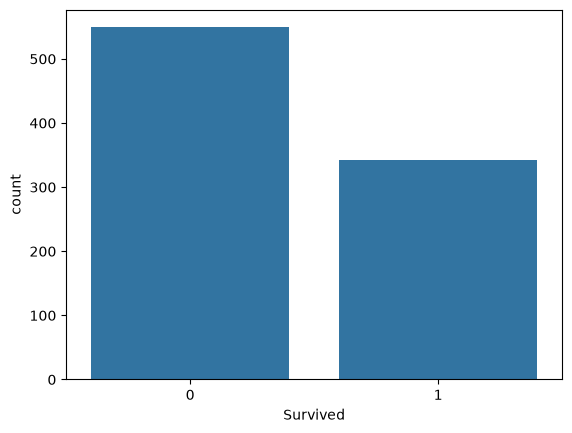

In [114]:
sns.countplot(
    data=df,
    x="Survived"
)

plt.show()

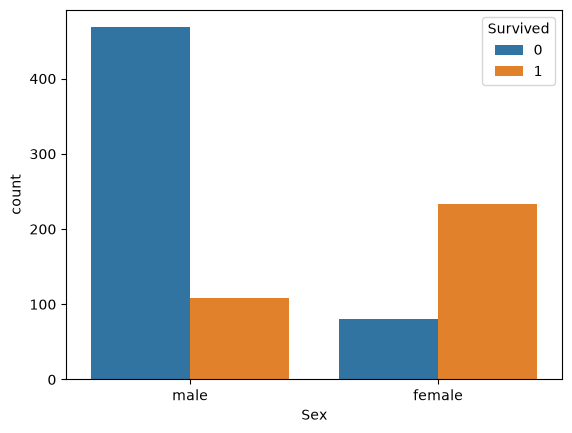

In [115]:
sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)

plt.show()

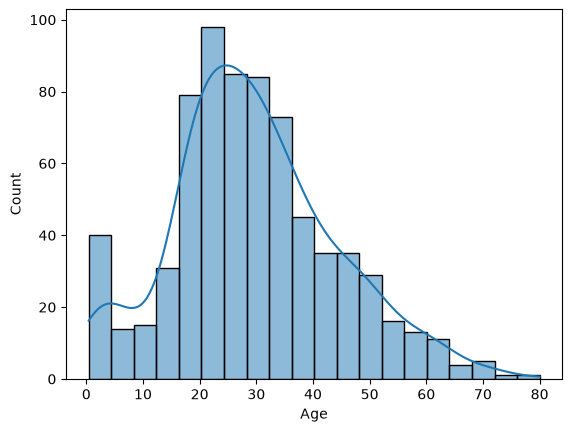

In [116]:
sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.show()

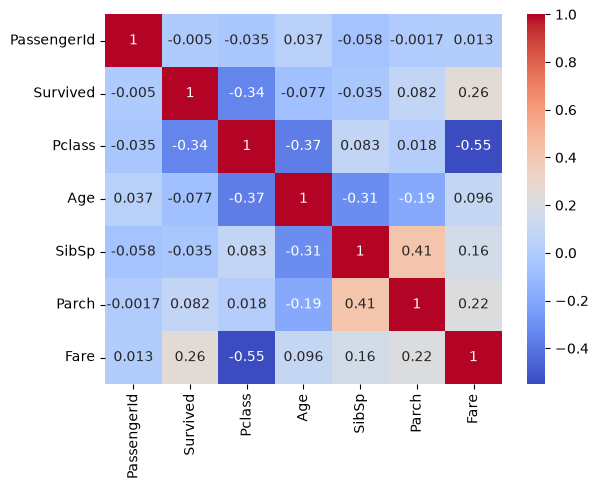

In [117]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [ ]:
# Select Features
features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked"
]

X = df[features]

y = df["Survived"]

In [119]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [120]:
# Define Feature Types
numeric_features = [

    "Age",

    "Fare"

]

categorical_features = [

    "Sex",

    "Embarked",

    "Pclass"

]

In [121]:
# Numeric Pipeline
numeric_pipeline = Pipeline([

    (

        "imputer",

        SimpleImputer(strategy="median")

    ),

    (

        "scaler",

        StandardScaler()

    )

])

In [122]:
# Categorical Pipeline
categorical_pipeline = Pipeline([

    (

        "imputer",

        SimpleImputer(

            strategy="most_frequent"

        )

    ),

    (

        "encoder",

        OneHotEncoder(

            handle_unknown="ignore"

        )

    )

])

In [123]:
# Combine Pipelines
preprocessor = ColumnTransformer([

    (

        "num",

        numeric_pipeline,

        numeric_features

    ),

    (

        "cat",

        categorical_pipeline,

        categorical_features

    )

])

In [ ]:
# Build Model Pipeline: Logistic Regression
logistic_pipeline = Pipeline([

    (

        "preprocessor",

        preprocessor

    ),

    (

        "model",

        LogisticRegression(

            max_iter=1000

        )

    )

])

In [126]:
# Random Forest
rf_pipeline = Pipeline([

    (

        "preprocessor",

        preprocessor

    ),

    (

        "model",

        RandomForestClassifier(

            random_state=42

        )

    )

])

In [127]:
# Train Models
logistic_pipeline.fit(

    X_train,

    y_train

)

rf_pipeline.fit(

    X_train,

    y_train

)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Pclass','Sex','Age','Fare','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not sp

In [128]:
# prediction
logistic_pred = logistic_pipeline.predict(

    X_test

)

rf_pred = rf_pipeline.predict(

    X_test

)

In [129]:
# Evaluate Models: Logistic Regression
print(

    accuracy_score(

        y_test,

        logistic_pred

    )

)

0.770949720670391


In [130]:
# Classification Report
print(

    classification_report(

        y_test,

        logistic_pred

    )

)

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       110
           1       0.72      0.67      0.69        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.77      0.77      0.77       179



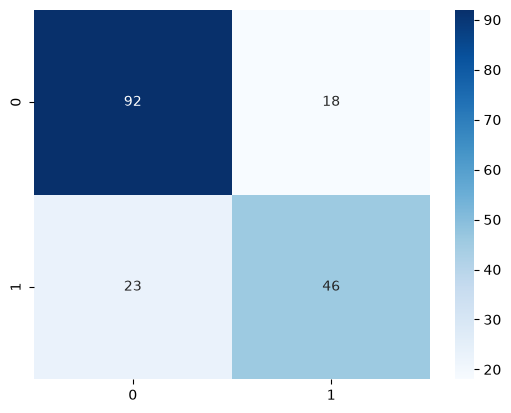

In [131]:
# Confusion matrix
cm = confusion_matrix(

    y_test,

    logistic_pred

)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.show()

In [132]:
# Evalution: Random Forest
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8156424581005587


In [133]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



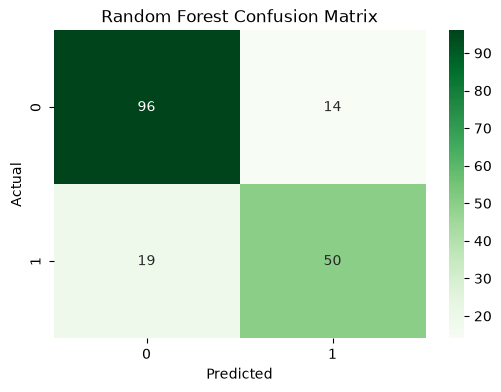

In [134]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [135]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Accuracy :", rf_accuracy)

Accuracy : 0.8156424581005587


In [ ]:
# You can also calculate each metric separately:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

print("Precision :", rf_precision)
print("Recall    :", rf_recall)
print("F1 Score  :", rf_f1)

Precision : 0.78125
Recall    : 0.7246376811594203
F1 Score  : 0.7518796992481203


In [137]:
# Compare Both Models
log_accuracy = accuracy_score(y_test, logistic_pred)
log_precision = precision_score(y_test, logistic_pred)
log_recall = recall_score(y_test, logistic_pred)
log_f1 = f1_score(y_test, logistic_pred)

In [138]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_accuracy, rf_accuracy],
    "Precision": [log_precision, rf_precision],
    "Recall": [log_recall, rf_recall],
    "F1 Score": [log_f1, rf_f1]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.770950    0.71875  0.666667  0.691729
1        Random Forest  0.815642    0.78125  0.724638  0.751880


In [139]:
comparison.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.815642,0.78125,0.724638,0.751880
0,Logistic Regression,0.770950,0.71875,0.666667,0.691729


In [140]:
# Professional Way to Compare Models
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Logistic Regression": [
        log_accuracy,
        log_precision,
        log_recall,
        log_f1
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]
})

print(comparison)

      Metric  Logistic Regression  Random Forest
0   Accuracy             0.770950       0.815642
1  Precision             0.718750       0.781250
2     Recall             0.666667       0.724638
3   F1 Score             0.691729       0.751880


In [141]:
# Save the Best Pipeline
joblib.dump(

    rf_pipeline,

    "titanic_pipeline.pkl"

)

['titanic_pipeline.pkl']

In [142]:
# Load Saved pipeline
pipeline = joblib.load(

    "titanic_pipeline.pkl"

)

In [143]:
# predict new passanger
new_passenger = pd.DataFrame({

    "Pclass":[1],

    "Sex":["female"],

    "Age":[29],

    "Fare":[100],

    "Embarked":["S"]

})

In [144]:
prediction = pipeline.predict(

    new_passenger

)

print(prediction)

[1]
